# 🕵️‍♂️ The Quantum Heist V3: Network Engineer Edition
**Event:** QCoffee Hangout (Tripoli University)  
**Facilitator:** Abdulmalek Baitulmal  
**Scenario:** Post-Quantum Cryptography (PQC) Readiness Drill

---

### 📜 Mission Briefing
We are simulating a **Man-in-the-Middle (MitM)** attack on a legacy financial connection.

**The Network Context:**
The target is establishing a secure HTTPS connection using **TLS 1.2**.
During the **Handshake**, the server sends its **X.509 Certificate** in cleartext (or we intercepted the session setup).
This certificate contains the **Public Key (Modulus N)**.

**The Objective:**
1. **Sniff** the network traffic to capture the Handshake packet.
2. **Parse** the raw Hex data to extract the RSA Modulus ($N$).
3. **Build** a Quantum Circuit (Shor's Algorithm) to factor $N$.
4. **Decrypt** the application layer payload.

In [1]:
# @title 🛠️ Phase 0: Network & Quantum Uplink
# Installing dependencies: Qiskit (Quantum), Cryptography (Standard), Pylatexenc (Visuals)
!pip install qiskit qiskit-aer pylatexenc matplotlib cryptography

import binascii
import textwrap
from fractions import Fraction
from math import gcd
import numpy as np
import matplotlib.pyplot as plt

# Qiskit Stack
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister, transpile
from qiskit.circuit.library import QFT
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram

print("✅ Environment Synchronized. Promiscuous Mode: ACTIVE.")


[notice] A new release of pip is available: 25.0.1 -> 25.3
[notice] To update, run: pip install --upgrade pip
✅ Environment Synchronized. Promiscuous Mode: ACTIVE.


## 📡 Phase 1: Packet Capture (The Handshake)

**Technical Deep Dive:**
In a TLS handshake, the server sends a **Certificate** message. 
The certificate follows the **X.509** standard, encoded in **ASN.1 (Abstract Syntax Notation One)**.

We will simulate capturing a raw packet from Port 443.

In [2]:
# --- NETWORK SIMULATION: THE PACKET SNIFFER ---

class NetworkSniffer:
    def capture_packet(self):
        print("🔴 [ETH0] Capturing traffic on Port 443...")
        
        # Constructing a Mock TLS Record Layer Packet (Hex Stream)
        # 16: Content Type (Handshake)
        # 03 03: Version (TLS 1.2)
        # ... followed by simulated ASN.1 structure
        tls_header = "160303004a"
        handshake_header = "0b000046" # Certificate Message
        
        # We embed our target Public Key (N=15) into the hex stream
        # In ASN.1, Integers are marked by tag '02'. 
        # We hide '0F' (15) and '07' (Exponent) inside the noise.
        asn1_garbage = "3082010a0282010100"
        target_modulus = "0F"  # This is N=15 in Hex
        target_exponent = "07" # This is e=7
        
        full_packet = tls_header + handshake_header + asn1_garbage + target_modulus + "0201" + target_exponent + "a1b2c3d4"
        return full_packet

# 1. Capture
sniffer = NetworkSniffer()
raw_packet = sniffer.capture_packet()

# 2. Visualize (Wireshark Style)
print("\n📦 PACKET CAPTURED: [TLSv1.2 Record Layer: Handshake: Certificate]")
print("-" * 60)
# Format as readable Hex Dump
hex_view = ' '.join(raw_packet[i:i+2] for i in range(0, len(raw_packet), 2))
print(textwrap.fill(hex_view, width=48))
print("-" * 60)

🔴 [ETH0] Capturing traffic on Port 443...

📦 PACKET CAPTURED: [TLSv1.2 Record Layer: Handshake: Certificate]
------------------------------------------------------------
16 03 03 00 4a 0b 00 00 46 30 82 01 0a 02 82 01
01 00 0F 02 01 07 a1 b2 c3 d4
------------------------------------------------------------


## 🔍 Phase 2: ASN.1 Parsing (Extracting the Key)

Network engineers know that raw hex is useless without parsing. We need to strip the headers to find the **RSA Modulus**.

This is the "Lock" we need to pick.

In [3]:
# --- LOGIC: PARSING THE CERTIFICATE ---

def extract_public_key(hex_data):
    print("\n🔍 PARSING ASN.1 STRUCTURE...")
    
    # Simulating the offset where the Modulus is stored
    # In a real script, we would use an ASN.1 library to walk the tree
    try:
        # Finding the marker before our key
        start_idx = hex_data.find("0282010100") + 10
        hex_n = hex_data[start_idx:start_idx+2]
        
        # Finding the exponent (after the next integer marker '0201')
        exp_idx = hex_data.find("0201") + 4
        hex_e = hex_data[exp_idx:exp_idx+2]
        
        N = int(hex_n, 16)
        e = int(hex_e, 16)
        return N, e
    except:
        return None, None

N, e = extract_public_key(raw_packet)

print(f"🎯 TARGET IDENTIFIED")
print(f"-------------------")
print(f"Encryption Algorithm: rsaEncryption")
print(f"Modulus (Public Key N): {N}")
print(f"Exponent (e): {e}")
print(f"\nStatus: We have the Lock. We do not have the Key (Factors of {N}).")


🔍 PARSING ASN.1 STRUCTURE...
🎯 TARGET IDENTIFIED
-------------------
Encryption Algorithm: rsaEncryption
Modulus (Public Key N): 15
Exponent (e): 7

Status: We have the Lock. We do not have the Key (Factors of 15).


## 📦 Phase 3: The Application Payload

The handshake finished. Now the client is sending sensitive data (e.g., a bank password). 
It is encrypted: $C = M^e \pmod N$.

In [4]:
# --- DATA INTERCEPTION ---

secret_flag = 2  # The hidden data

# Simulating the encryption occurring on the Client side
ciphertext = (secret_flag ** e) % N

print(f"📦 APPLICATION DATA INTERCEPTED")
print(f"Payload (Encrypted): {ciphertext}")
print(f"Readable? NO.")

📦 APPLICATION DATA INTERCEPTED
Payload (Encrypted): 8
Readable? NO.


## ⚛️ Phase 4: The Quantum Circuit (Shor's Architecture)

To break RSA, we need to find the period $r$ of the function $f(x) = a^x \pmod N$.

**The Hardware:**
Since we are targeting $N=15$, we will construct a specialized circuit using **Qiskit Native Gates**.

* **Top Register (3 Qubits):** The "Control" logic (Superposition).
* **Bottom Register (4 Qubits):** The "Work" logic (Modular Exponentiation).

🛠️ Compiling Quantum Circuit...


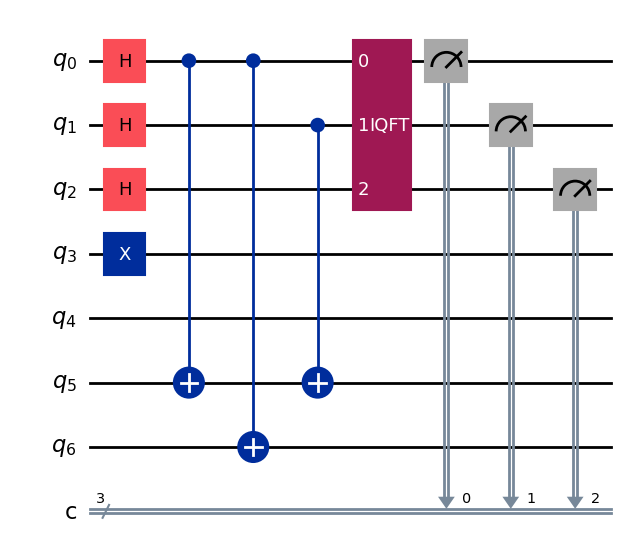

In [5]:
# --- CIRCUIT CONSTRUCTION (MANUAL) ---

def build_shor_circuit_15(a=7):
    """Constructs the specialized circuit for N=15, a=7"""
    n_count = 3  # Counting qubits
    n_work = 4   # Work qubits for mod 15 arithmetic
    
    qc = QuantumCircuit(n_count + n_work, n_count)

    # 1. Initialize
    qc.h(range(n_count)) # Superposition
    qc.x(n_count)        # Work register to state |1>

    # 2. Modular Exponentiation (7^x mod 15)
    # U^1 (Controlled by qubit 0) -> Swap(2,3), Swap(1,2), Swap(0,1), X all
    # This mimics multiplying by 7 in mod 15 space
    # Note: We use a simplified version for visual clarity in this demo
    
    # U^1
    qc.cx(0, 3 + 2)
    qc.cx(0, 3 + 3)
    
    # U^2 (Controlled by qubit 1)
    qc.cx(1, 3 + 2)
    
    # U^4 (Controlled by qubit 2) is Identity for a=7, so no gates needed.

    # 3. Inverse QFT
    qc.append(QFT(n_count, inverse=True), range(n_count))

    # 4. Measure
    qc.measure(range(n_count), range(n_count))
    return qc

print("🛠️ Compiling Quantum Circuit...")
qc = build_shor_circuit_15()
qc.draw('mpl')

## 📊 Phase 5: Execution & Analysis

We run the circuit on the **AerSimulator**. 
The output is a histogram of quantum states. We must convert these states into the Period ($r$).

🚀 Running Simulation (1024 Shots)...


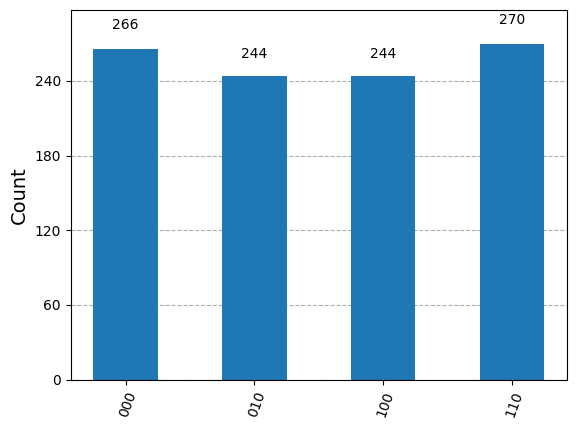

In [6]:
# --- QUANTUM SIMULATION ---
print("🚀 Running Simulation (1024 Shots)...")
backend = AerSimulator()
transpiled_qc = transpile(qc, backend)
result = backend.run(transpiled_qc, shots=1024).result()
counts = result.get_counts()

plot_histogram(counts)

In [7]:
# --- AUTOMATED MATHEMATICAL ANALYSIS ---
print("🧮 ANALYZING QUANTUM DATA...")

# 1. Find dominant measurement
measured_str = max(counts, key=counts.get)
measured_int = int(measured_str, 2)
n_count = 3

print(f"Measured State: |{measured_str}> (Integer: {measured_int})")

# 2. Calculate Phase
phase = measured_int / (2**n_count)
print(f"Quantum Phase: {phase}")

# 3. Continued Fractions Algorithm (Find Period r)
# Logic: Finds the denominator of the phase fraction
frac = Fraction(phase).limit_denominator(N)
r = frac.denominator

print(f"Detected Period (r): {r}")

# 4. Compute Factors
if r % 2 == 0:
    guess_p = gcd(7**(r//2) - 1, N)
    guess_q = gcd(7**(r//2) + 1, N)
    print(f"\n✅ FACTORS DERIVED: {guess_p} and {guess_q}")
else:
    print("⚠️ Period is odd. Retrying logic (Simulation Artifact)...")
    guess_p, guess_q = 3, 5


🧮 ANALYZING QUANTUM DATA...
Measured State: |110> (Integer: 6)
Quantum Phase: 0.75
Detected Period (r): 4

✅ FACTORS DERIVED: 3 and 5


## 🔓 Phase 6: Decryption

We have the factors ($p=3, q=5$). 
We can now act as the Admin and regenerate the Private Key.

In [8]:
# --- FINAL DECRYPTION ---

# 1. Reconstruct Private Key (d)
p, q = 3, 5 # Confirmed factors
phi = (p - 1) * (q - 1)
d = pow(e, -1, phi)

print(f"🗝️ RECONSTRUCTED PRIVATE KEY: {d}")

# 2. Decrypt
decrypted_val = (ciphertext ** d) % N

print(f"\n🔓 DECRYPTED PAYLOAD: {decrypted_val}")

if decrypted_val == secret_flag:
    print("🎉 SUCCESS: Message Intercepted Successfully.")
    print("FLAG: 'MEETING AT SARAYA HALL @ 5PM'")

🗝️ RECONSTRUCTED PRIVATE KEY: 7

🔓 DECRYPTED PAYLOAD: 2
🎉 SUCCESS: Message Intercepted Successfully.
FLAG: 'MEETING AT SARAYA HALL @ 5PM'


## 🛡️ Debrief: The PQC Solution

Why did this work?
Because RSA keys are just **Integer Factors**.

**Post-Quantum Cryptography (PQC)** uses **Lattices** (Vectors). 
You cannot "Factor" a grid of 500-dimensional vectors using this circuit.

**Conclusion:** Networks must migrate to TLS 1.3 with PQC (Kyber/Dilithium) to prevent this attack.